# GS_LH Demo — Bayesian $L_{1/2}$ Regression in PyTorch & JAX

This notebook shows how to use the **GS_LH** Gibbs samplers for the Bayesian
$L_{1/2}$ regression of Ke & Fan (2024, JCGS):

$$Y = X\beta + \varepsilon, \qquad \varepsilon \sim \mathcal N_n(0, \sigma^2 I_n),
\qquad \pi(\tilde\beta_j \mid \lambda) = \frac{\lambda^2}{4} e^{-\lambda\sqrt{|\tilde\beta_j|}},
\quad \tilde\beta_j = \beta_j/\sigma,$$

with hyperpriors $\lambda \sim \mathrm{Gamma}(a, b)$ and
$\sigma^2 \sim \mathrm{InvGamma}(a_1, b_1)$. High-dimensional designs
($p > n$) are supported throughout.

- PyTorch version: `from GS_LH import GS_LH` (float64 recommended)
- JAX version: `from GS_LH_JAX import GS_LH` (fixed float32, XLA-compiled `lax.scan`)

Both share the same interface. See the README and the accompanying note
(`On the Connection between Dirichlet–Laplace Prior and L1_2 Prior.md`) for
details — notably that the $L_{1/2}$ prior **is** the Dirichlet–Laplace prior
at concentration $a = 3/2$.

Requirements: `pip install numpy torch` (and `jax` for the last section).

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
# ^ Windows + conda only: numpy (MKL) and torch each bundle the Intel OpenMP
#   runtime; this allows the duplicate (same workaround as test/_test_vs_torch.py).

import numpy as np
import torch

from GS_LH import GS_LH

torch.set_default_dtype(torch.float64)   # float64 recommended for the PyTorch version
print("torch", torch.__version__)

torch 2.14.0+cu132


## 1. Simulate a sparse regression problem ($p \gg n$)

$n = 100$ observations, $p = 500$ candidate predictors, 5 true signals,
$\sigma = 1$. The columns of $X$ are standardized to $\|X_j\|^2 = n$
(the model assumption; alternatively pass `standardize=True` — see §5).

In [2]:
rng = np.random.default_rng(1)
n, p = 100, 500
beta_true = np.zeros(p); beta_true[:5] = [2.0, -1.5, 1.2, 0.9, -0.7]
sigma_true = 1.0

X = rng.standard_normal((n, p))
X *= n ** 0.5 / np.linalg.norm(X, axis=0)          # ||X_j||^2 = n
Y = X @ beta_true + sigma_true * rng.standard_normal(n)

X_t, Y_t = torch.from_numpy(X), torch.from_numpy(Y)
print(f"n = {n}, p = {p}, 5 signals, sigma = {sigma_true}")

n = 100, p = 500, 5 signals, sigma = 1.0


## 2. Run the Gibbs sampler (`fast` method, $p \ge n$)

`n_iter` counts the draws **kept** (after `burnin`). The default
$\sigma^2$ prior is $\mathrm{InvGamma}(1, 1)$ — deliberately *not* the
near-Jeffreys $(10^{-3}, 10^{-3})$, which in the $p \gg n$ regime lets the
posterior collapse onto near-interpolating solutions (see §3 and note §4.5).
`seed` makes the chain fully reproducible.

In [3]:
out = GS_LH(X_t, Y_t, n_iter=4000, burnin=1000, seed=42)

print(f"method      : {out['method']}")
print(f"runtime     : {out['runtime_sec']:.1f} s  ({5000 / out['runtime_sec']:.0f} it/s)")
print(f"sigma2 mean : {float(out['sigma2'].mean()):.3f}")
print(f"beta draws  : {tuple(out['beta'].shape)}   (torch, float64)")
print(f"output keys : {sorted(out.keys())}")

method      : fast
runtime     : 4.6 s  (1076 it/s)
sigma2 mean : 0.358
beta draws  : (4000, 500)   (torch, float64)
output keys : ['beta', 'method', 'preprocess', 'runtime_sec', 'sigma2', 'w_final']


## 3. Posterior summary

Shrinkage priors do exactly what their name says: the 5 signals are
recovered (with the usual shrinkage-induced bias toward 0), while the 495
noise coefficients are squeezed toward zero. The posterior of $\sigma^2$ in
$p \gg n$ is deflated — a documented property of the *posterior itself*
(note §4.5), mitigated by the $\mathrm{InvGamma}(1,1)$ default and by any
more informative choice.

In [4]:
bm, bs = out["beta"].mean(0), out["beta"].std(0)

print("signal recovery (posterior mean vs true):")
for j in range(5):
    print(f"  beta[{j}]: mean = {float(bm[j]):+.3f}, sd = {float(bs[j]):.3f}, true = {beta_true[j]:+.1f}")
print(f"noise coefficients: max |posterior mean| = {float(bm[5:].abs().max()):.3f}")
print(f"sigma^2: posterior mean = {float(out['sigma2'].mean()):.3f} (true {sigma_true})")

signal recovery (posterior mean vs true):
  beta[0]: mean = +1.929, sd = 0.140, true = +2.0
  beta[1]: mean = -1.384, sd = 0.142, true = -1.5
  beta[2]: mean = +0.981, sd = 0.144, true = +1.2
  beta[3]: mean = +0.795, sd = 0.141, true = +0.9
  beta[4]: mean = -0.712, sd = 0.140, true = -0.7
noise coefficients: max |posterior mean| = 0.161
sigma^2: posterior mean = 0.358 (true 1.0)


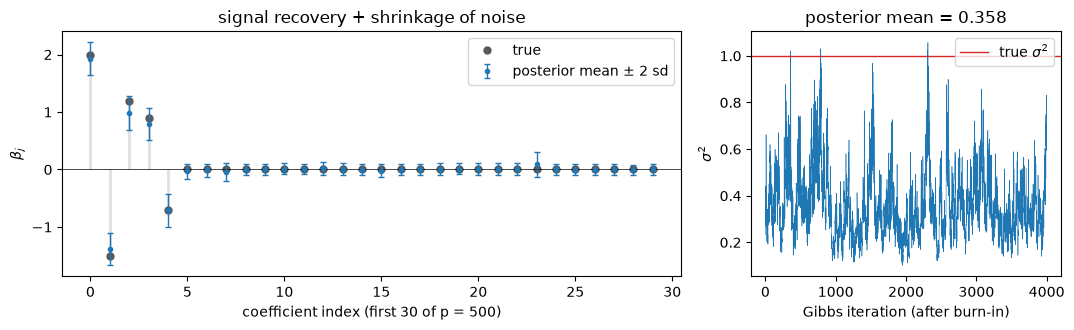

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), gridspec_kw={"width_ratios": [2, 1]})

ax = axes[0]
idx = np.arange(30)
ax.vlines(idx, 0, beta_true[:30], color="0.88", lw=2, zorder=1)
ax.plot(idx, beta_true[:30], "o", color="0.35", ms=5, label="true", zorder=2)
ax.errorbar(idx, bm[:30].numpy(), yerr=2 * bs[:30].numpy(), fmt=".",
            color="tab:blue", lw=1, capsize=2, zorder=3,
            label=r"posterior mean $\pm$ 2 sd")
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("coefficient index (first 30 of p = 500)")
ax.set_ylabel(r"$\beta_j$")
ax.set_title("signal recovery + shrinkage of noise")
ax.legend()

ax = axes[1]
ax.plot(out["sigma2"].numpy(), lw=0.4)
ax.axhline(sigma_true, color="tab:red", lw=1, label=r"true $\sigma^2$")
ax.set_xlabel("Gibbs iteration (after burn-in)")
ax.set_ylabel(r"$\sigma^2$")
ax.set_title(f"posterior mean = {float(out['sigma2'].mean()):.3f}")
ax.legend()

plt.tight_layout(); plt.show()

> **Caveat ($p \gg n$):** with a near-Jeffreys $\sigma^2$ prior the
> sampler above would report $\sigma^2 \approx 0.02$ instead of $≈ 0.3$–$0.4$
> here — the chain is *correct*, the interpolated posterior really is that
> degenerate. Use $a_1 \ge 1$ (the default) or a genuinely informative
> $\sigma^2$ prior; $\hat\beta$ is unaffected either way. See note §4.5
> and the WARNING in `GS_LH/sigma2_sample.py`.

## 4. $n > p$: the `direct` method

`method="auto"` (default) picks the exact algorithm pairing by regime:
`fast` ($p \ge n$, $n \times n$ system) or `direct` ($n > p$, $p \times p$
system). Here $n = 250 > p = 60$, so the `direct` pairing is used. With
$p < n$ there is no interpolation degeneracy and $\sigma^2$ is recovered
well even with weak priors.

In [6]:
n2, p2 = 250, 60
beta2 = np.zeros(p2); beta2[[0, 5, 20]] = [1.5, -1.0, 0.8]
X2 = rng.standard_normal((n2, p2)); X2 *= n2 ** 0.5 / np.linalg.norm(X2, axis=0)
Y2 = X2 @ beta2 + 0.8 * rng.standard_normal(n2)

out2 = GS_LH(torch.from_numpy(X2), torch.from_numpy(Y2), n_iter=3000, burnin=500, seed=7)
bm2 = out2["beta"].mean(0)

print(f"method = {out2['method']}   runtime = {out2['runtime_sec']:.1f} s")
print("posterior means:", [f"{float(bm2[j]):+.3f}" for j in (0, 5, 20)],
      "(true [+1.5, -1.0, +0.8])")
print(f"sigma2 mean = {float(out2['sigma2'].mean()):.3f} (true {0.8 ** 2:.2f})")

method = direct   runtime = 2.4 s
posterior means: ['+1.493', '-1.041', '+0.740'] (true [+1.5, -1.0, +0.8])
sigma2 mean = 0.629 (true 0.64)


## 5. Raw data with an intercept: `standardize=True`

Real data rarely comes centered/scaled. With `standardize=True` (the
default) the driver centers $Y$, centers the columns of $X$ and rescales
them to $\|X_j\|^2 = n$, and returns the statistics needed to map the
posterior back to the original scale:
`beta_orig_j = beta_j / x_scale_j`, `intercept = y_mean - x_mean · beta_orig`.

In [7]:
beta3 = np.zeros(p2); beta3[[0, 5, 20]] = [1.5, -1.0, 0.8]
X3 = rng.standard_normal((n2, p2)) * (np.arange(p2) % 5 + 1) + 0.7   # arbitrary scales/means
Y3 = 2.5 + X3 @ beta3 + 0.5 * rng.standard_normal(n2)                # intercept 2.5

out3 = GS_LH(torch.from_numpy(X3), torch.from_numpy(Y3), n_iter=3000, burnin=1000,
             standardize=True, seed=5)
pre = out3["preprocess"]
beta3_hat = out3["beta"].mean(0).numpy() / pre["x_scale"]
intercept = pre["y_mean"] - pre["x_mean"] @ beta3_hat

print("recovered beta:", [f"{beta3_hat[j]:+.3f}" for j in (0, 5, 20)],
      "(true [+1.5, -1.0, +0.8])")
print(f"recovered intercept: {intercept:.3f} (true 2.5)")

recovered beta: ['+1.473', '-0.974', '+0.745'] (true [+1.5, -1.0, +0.8])
recovered intercept: 2.503 (true 2.5)


## 6. Warm restarts: `w_final` → `w0`

The Markov state carried between iterations is only the scale vector
$w = \tau/\lambda^2$ ($\beta$ and $\sigma^2$ are regenerated every pass,
so they never need initialization). Continuing a chain is a one-liner.

In [8]:
first = GS_LH(X_t, Y_t, n_iter=1000, burnin=200, seed=123)
cont  = GS_LH(X_t, Y_t, n_iter=1000, burnin=0, seed=321, w0=first["w_final"])

combined = torch.cat([first["beta"], cont["beta"]]).mean(0)
print(f"max |mean diff| vs the 4000-draw chain of §2: "
      f"{float((combined - out['beta'].mean(0)).abs().max()):.3f}  (Monte Carlo noise)")
print(f"continued-chain sigma2 mean: {float(cont['sigma2'].mean()):.3f}")

max |mean diff| vs the 4000-draw chain of §2: 0.015  (Monte Carlo noise)
continued-chain sigma2 mean: 0.321


## 7. The JAX version

Same interface, fixed float32, the whole chain run as a chunked
`jax.lax.scan` (XLA-compiled; `runtime_sec` excludes the one-time JIT
compilation). Inputs/outputs are NumPy arrays. Skipped gracefully if JAX
is not installed.

In [9]:
try:
    from GS_LH_JAX import GS_LH as GS_LH_jax
except ImportError:
    print("JAX not installed — pip install jax (see README). Section skipped.")
else:
    out_j = GS_LH_jax(X, Y, n_iter=4000, burnin=1000, seed=42)

    print(f"method      : {out_j['method']}")
    print(f"runtime     : {out_j['runtime_sec']:.1f} s  (excl. JIT compilation)")
    print(f"beta draws  : {out_j['beta'].shape}   (numpy, float32)")
    print(f"sigma2 mean : {float(out_j['sigma2'].mean()):.3f}")
    d = np.abs(out_j["beta"].mean(0) - bm.numpy()).max()
    print(f"max |posterior mean diff| vs the PyTorch (float64) chain: {d:.4f}")
    print("(different RNG stream and precision — the chains differ, the posteriors agree)")

method      : fast
runtime     : 1.3 s  (excl. JIT compilation)
beta draws  : (4000, 500)   (numpy, float32)
sigma2 mean : 0.356
max |posterior mean diff| vs the PyTorch (float64) chain: 0.0091
(different RNG stream and precision — the chains differ, the posteriors agree)


## Summary

| what | how |
| --- | --- |
| run the sampler | `out = GS_LH(X, Y, n_iter=..., burnin=..., seed=...)` |
| posterior draws | `out["beta"]` $(n_{iter}, p)$, `out["sigma2"]` $(n_{iter},)$ |
| algorithm choice | `method="auto"` → `fast` ($p \ge n$) / `direct` ($n > p$) |
| raw data | `standardize=True` (default) + `out["preprocess"]` |
| continue a chain | `GS_LH(..., w0=out["w_final"])` |
| JAX (float32) | `from GS_LH_JAX import GS_LH` — identical arguments |

Further reading: the README (API reference, the $p \gg n$ $\sigma^2$
caveat, benchmarks) and the mathematical note
(`On the Connection between Dirichlet–Laplace Prior and L1_2 Prior.md`)
proving that the $L_{1/2}$ prior is the Dirichlet–Laplace prior at
$a = 3/2$. Test suites: `test/` (PyTorch) and `test_JAX/` (JAX).